# IMDB Movie Review Sentiment Analysis — Full Experiment

**Goal:** Predict whether a review is `positive` or `negative` using classic ML models.

**Pipeline stages covered in this notebook:**
1. Imports & Setup
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Preprocessing (text normalization)
6. Feature Engineering (TF-IDF vectorization)
7. Train/Test Split
8. Model Experiments — run **individually** first (for learning), then as an **automated 3-model pipeline**
   - Logistic Regression
   - Random Forest
   - XGBoost
9. Evaluation (metrics + confusion matrix for every model)
10. Model Comparison Table + Best Model Selection
11. Tunable Hyperparameters — what to change to try to squeeze out more accuracy

> Nothing in this notebook has been executed. Copy-paste and run cell by cell — each cell's comments explain *why* it exists, not just *what* it does, so you can use it as a reference later.


## 1. Imports & Setup
Everything the notebook needs, in one place.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [90]:
import os

LOCAL_FILE_PATH = os.getenv(
    "LOCAL_DATA_PATH",
    "../data/IMDB.csv"
 )

df = pd.read_csv(LOCAL_FILE_PATH)
print(df.shape)
df.head()

(1000, 2)


,review,sentiment
0,Film version of Sandra Bernhard's one-woman of...,negative
1,I switched this on (from cable) on a whim and ...,positive
2,The `plot' of this film contains a few holes y...,negative
3,"Some amusing humor, some that falls flat, some...",negative
4,What can you say about this movie? It was not ...,negative


## 3. Exploratory Data Analysis (EDA)

We check: class balance, missing values, duplicate rows, review length distribution,
and a quick word-frequency peek. This tells us whether we need to worry about class
imbalance (we don't have a strong imbalance here, but always verify) and whether the
text needs heavy cleaning.

In [47]:
# Basic info
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     1000 non-null   object
 1   sentiment  1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB

Missing values:
 review       0
sentiment    0
dtype: int64

Duplicate rows: 0


In [48]:
# Class balance
print(df['sentiment'].value_counts())


sentiment
negative    517
positive    483
Name: count, dtype: int64


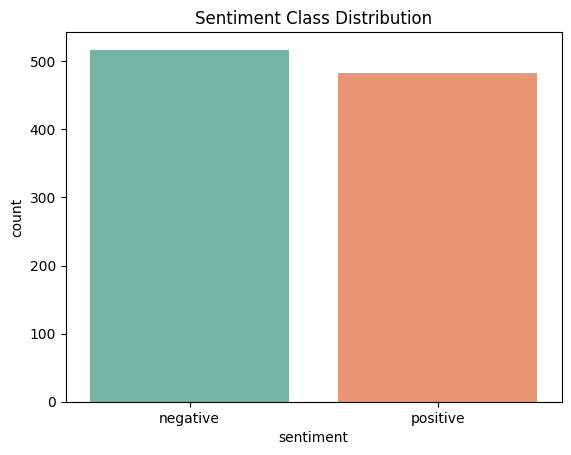

In [49]:
plt.figure()
sns.countplot(data=df, x='sentiment', hue='sentiment', palette='Set2', legend=False)
plt.title('Sentiment Class Distribution')
plt.show()

In [50]:
# Review length distribution (character count and word count)
df['char_len'] = df['review'].str.len()
df['word_len'] = df['review'].str.split().apply(len)

print(df[['char_len', 'word_len']].describe())

          char_len     word_len
count  1000.000000  1000.000000
mean   1312.690000   232.028000
std    1005.221885   175.342563
min      80.000000    14.000000
25%     695.000000   124.000000
50%     966.000000   172.000000
75%    1562.750000   280.250000
max    7164.000000  1316.000000


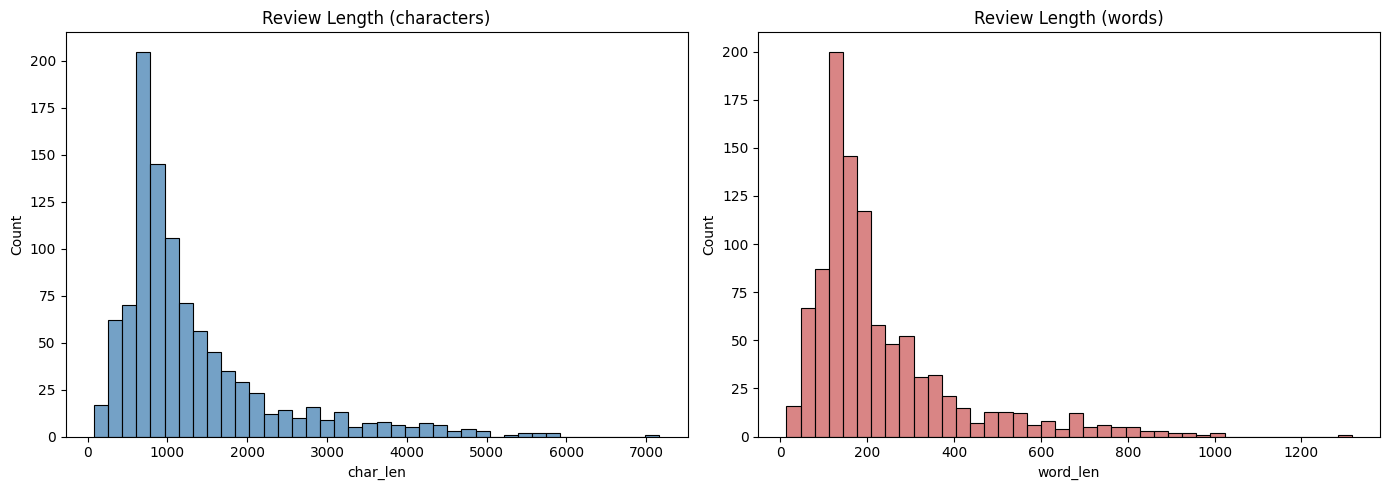

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['char_len'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Review Length (characters)')
sns.histplot(df['word_len'], bins=40, ax=axes[1], color='indianred')
axes[1].set_title('Review Length (words)')
plt.tight_layout()
plt.show()

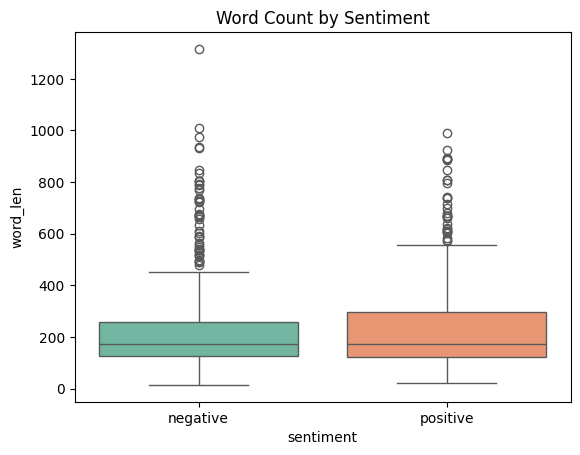

In [52]:
plt.figure()
sns.boxplot(data=df, x='sentiment', y='word_len', hue='sentiment', palette='Set2', legend=False)
plt.title('Word Count by Sentiment')
plt.show()


In [53]:
# Quick look at most frequent raw words (before cleaning) just to sanity-check content
from collections import Counter

all_words = ' '.join(df['review']).lower().split()
common = Counter(all_words).most_common(20)
print(common)

[('the', 12902), ('a', 6444), ('and', 6228), ('of', 5654), ('to', 5314), ('is', 4116), ('in', 3667), ('i', 2837), ('this', 2800), ('that', 2700), ('it', 2612), ('/><br', 2086), ('was', 1923), ('for', 1728), ('as', 1599), ('with', 1594), ('but', 1518), ('on', 1282), ('movie', 1208), ('are', 1207)]


## 4. Data Cleaning

IMDB review text typically has HTML tags (`<br />`), punctuation, numbers, and mixed
casing. We remove/normalize these so the vectorizer sees clean tokens instead of noise.

We also drop exact duplicate rows (if any) and confirm there are no nulls.

In [54]:
import re

In [55]:
# Drop exact duplicate reviews (keep first occurrence)
before = len(df)
df = df.drop_duplicates(subset='review').reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows")

Dropped 0 duplicate rows


In [56]:
# Drop nulls just in case (defensive coding — dataset currently has none)
df = df.dropna(subset=['review', 'sentiment']).reset_index(drop=True)
print(df.shape)

(1000, 4)


In [57]:
def clean_text(text):
    """Basic cleaning: lowercase, strip HTML tags, remove punctuation/numbers,
    collapse whitespace. Kept separate from stopword removal/lemmatization so you
    can inspect the intermediate output."""
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)              # remove HTML tags e.g. <br />
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()         # collapse whitespace
    return text


In [58]:
df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(3)

,review,clean_review
0,Film version of Sandra Bernhard's one-woman of...,film version of sandra bernhard s one woman of...
1,I switched this on (from cable) on a whim and ...,i switched this on from cable on a whim and wa...
2,The `plot' of this film contains a few holes y...,the plot of this film contains a few holes you...


## 5. Preprocessing (Text Normalization)

Stopword removal + lemmatization. This reduces vocabulary size and noise before
vectorization (e.g. "running", "ran", "runs" -> "run").

**Tunable knob:** you can try *stemming* (faster, cruder — `nltk.stem.PorterStemmer`)
instead of lemmatization, or skip stopword removal entirely and let TF-IDF's
`max_df` handle common words statistically — try both and compare downstream accuracy.

In [59]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\Pranab
[nltk_data]     Samanta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Pranab
[nltk_data]     Samanta\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Pranab
[nltk_data]     Samanta\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [60]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)



In [61]:
#Reove the stopaords

df['processed_review'] = df['clean_review'].apply(preprocess)
df[['clean_review', 'processed_review']].head(3)

,clean_review,processed_review
0,film version of sandra bernhard s one woman of...,film version sandra bernhard one woman broadwa...
1,i switched this on from cable on a whim and wa...,switched cable whim treated quite surprise alt...
2,the plot of this film contains a few holes you...,plot film contains hole could drive massive tr...


In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

In [63]:
# Encode target: negative -> 0, positive -> 1
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
df[['sentiment', 'label']].drop_duplicates()


{'negative': np.int64(0), 'positive': np.int64(1)}


,sentiment,label
0,negative,0
1,positive,1


## 6. Feature Engineering — TF-IDF Vectorization

We convert cleaned text into numeric vectors using **TF-IDF** (Term Frequency –
Inverse Document Frequency), which weighs words by how distinctive they are to a
document relative to the whole corpus (better than raw counts for this task).

**Tunable knobs (the ones most worth experimenting with):**
- `max_features`: vocabulary size cap. Try 3000 / 5000 / 10000 — bigger can help
  accuracy but risks overfitting on a small (1000-row) dataset and slows training.
- `ngram_range`: `(1,1)` = unigrams only, `(1,2)` = unigrams + bigrams (captures
  phrases like "not good"). Bigrams often help sentiment tasks but increase
  dimensionality a lot.
- `min_df` / `max_df`: drop terms that are too rare (`min_df=2` -> ignore words
  seen in <2 documents) or too common (`max_df=0.9` -> ignore words in >90% of
  documents, similar effect to stopword removal).
- `sublinear_tf=True`: dampens the effect of very high term counts (log scaling),
  usually a small but free accuracy bump.

In [64]:
tfidf = TfidfVectorizer(
    max_features=5000,     # <-- tune: 3000 / 5000 / 10000
    ngram_range=(1, 2),    # <-- tune: (1,1) vs (1,2)
    min_df=2,              # <-- tune
    max_df=0.9,            # <-- tune
    sublinear_tf=True
)

In [65]:
X = tfidf.fit_transform(df['processed_review'])
y = df['label']

In [66]:
print("Feature matrix shape:", X.shape)

Feature matrix shape: (1000, 5000)


## 7. Train/Test Split

`stratify=y` keeps the positive/negative ratio the same in both splits — important
for fair evaluation, especially if the classes were imbalanced.

In [67]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         
    random_state=RANDOM_STATE,
    stratify=y
)

In [69]:
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (800, 5000)
Test shape : (200, 5000)


## 8A. Individual Model Runs (for learning)

Below, each of the three models is trained and evaluated **on its own**, step by
step, so you can see exactly what each pipeline stage does in isolation. This is
the same logic as the automated pipeline in section 8B — just unrolled.

### 8A.1 Logistic Regression (baseline)

A linear model — fast, interpretable, and a strong baseline for sparse TF-IDF
text features. Good first model to sanity-check the pipeline.

**Tunable knobs:**
- `C`: inverse regularization strength. Lower = more regularization (simpler
  model, less overfitting). Try 0.1, 1, 10.
- `penalty`: `'l2'` (default) vs `'l1'` (sparser weights, needs `solver='liblinear'`).
- `class_weight='balanced'`: useful if classes were imbalanced (not strictly
  needed here since classes are close to balanced).

In [70]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [72]:
log_reg = LogisticRegression(
    C=1.0,                  
    penalty='l2',           
    solver='liblinear',
    max_iter=1000,
    random_state=RANDOM_STATE
)

In [73]:
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

In [74]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC :", roc_auc_score(y_test, y_proba_lr))

Logistic Regression
              precision    recall  f1-score   support

    negative       0.85      0.82      0.83       103
    positive       0.81      0.85      0.83        97

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200

Accuracy: 0.83
ROC AUC : 0.9107196476829147


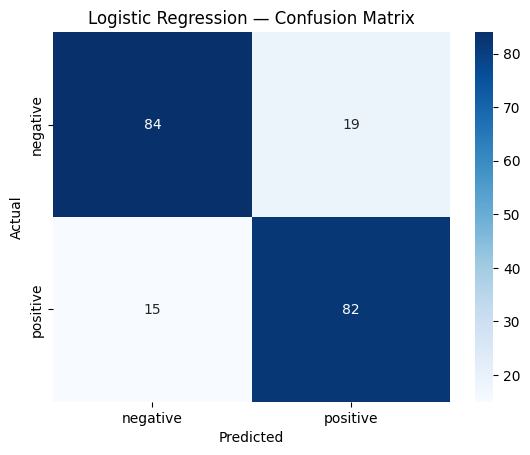

In [75]:
# Confusion matrix — Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### 8A.2 Random Forest

An ensemble of decision trees — captures non-linear patterns, less sensitive to
feature scaling, but can be slower and more prone to overfitting on
high-dimensional sparse TF-IDF data than Logistic Regression.

**Tunable knobs:**
- `n_estimators`: number of trees. More = usually better but slower (try 100,
  300, 500).
- `max_depth`: caps tree depth to fight overfitting (try `None`, 20, 50).
- `min_samples_leaf`: minimum samples per leaf; higher = smoother/less overfit.
- `max_features`: features considered per split (`'sqrt'` is a common default
  for classification).

In [76]:
rf = RandomForestClassifier(
    n_estimators=300,       
    max_depth=None,         
    min_samples_leaf=1,     
    max_features='sqrt',    
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [77]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC :", roc_auc_score(y_test, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

    negative       0.80      0.72      0.76       103
    positive       0.73      0.80      0.76        97

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.76      0.76       200

Accuracy: 0.76
ROC AUC : 0.8644780302272045


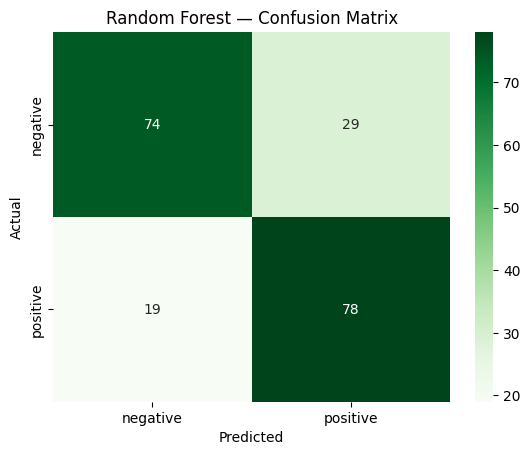

In [78]:
# Confusion matrix — Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 8A.3 XGBoost

Gradient-boosted trees — usually the strongest of the three "classic" ML options
for tabular/sparse features, at the cost of more hyperparameters and longer
training time.

**Tunable knobs:**
- `n_estimators`: number of boosting rounds (try 200–800).
- `learning_rate` (`eta`): smaller = more robust but needs more `n_estimators`
  (try 0.01–0.3).
- `max_depth`: tree depth per boosting round (try 3–8; text/TF-IDF usually likes
  shallower trees than tabular numeric data).
- `subsample` / `colsample_bytree`: row/column sampling per tree — helps prevent
  overfitting (try 0.7–1.0).
- `reg_alpha` / `reg_lambda`: L1/L2 regularization on leaf weights.

In [79]:
xgb = XGBClassifier(
    n_estimators=400,        # <-- tune
    learning_rate=0.1,       # <-- tune
    max_depth=6,             # <-- tune
    subsample=0.8,           # <-- tune
    colsample_bytree=0.8,    # <-- tune
    reg_alpha=0.0,           # <-- tune
    reg_lambda=1.0,          # <-- tune
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

In [80]:
print("XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC :", roc_auc_score(y_test, y_proba_xgb))

XGBoost
              precision    recall  f1-score   support

    negative       0.77      0.71      0.74       103
    positive       0.71      0.77      0.74        97

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.74      0.74      0.74       200

Accuracy: 0.74
ROC AUC : 0.8470623561205085


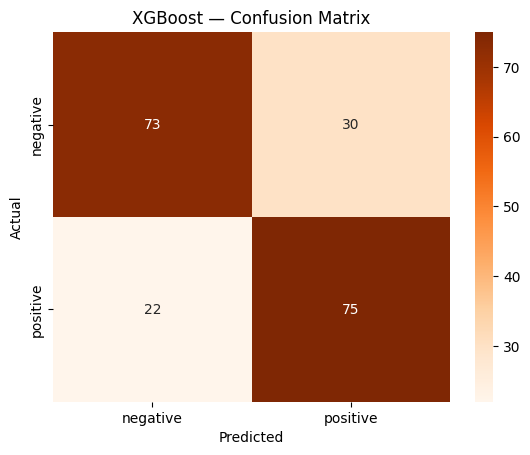

In [81]:
# Confusion matrix — XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8B. Automated 3-Model Pipeline

Same three models, but run in a loop so they execute one after another
automatically. This is the pattern you'd use in a `.py` script: define a dict of
models, loop over it, fit/predict/score each, and collect results into one table.
Handy once you already trust the logic from section 8A and just want to iterate
fast (e.g. after changing TF-IDF parameters above).

In [82]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, penalty='l2', solver='liblinear', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

results = []
fitted_models = {}   # keep trained models around for later (e.g. ROC plot)

for name, model in models.items():
    print(f"Training: {name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
    })
    fitted_models[name] = model

print("Done.")


Training: Logistic Regression ...
Training: Random Forest ...
Training: XGBoost ...
Done.


## 9. Evaluation — Comparison Table & Charts

In [83]:
results_df = pd.DataFrame(results).set_index('Model').sort_values('F1-score', ascending=False)
results_df


,Accuracy,Precision,Recall,F1-score,ROC AUC
Model,,,,,
Logistic Regression,0.83,0.811881,0.845361,0.828283,0.910720
Random Forest,0.76,0.728972,0.804124,0.764706,0.864478
XGBoost,0.74,0.714286,0.773196,0.742574,0.847062


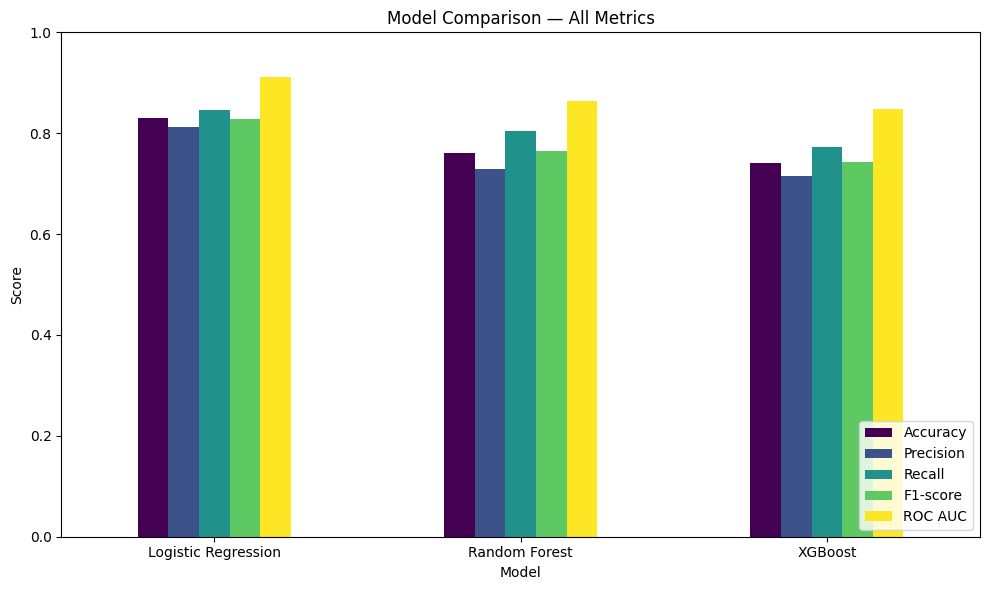

In [84]:
# Bar chart comparing all metrics across models
results_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


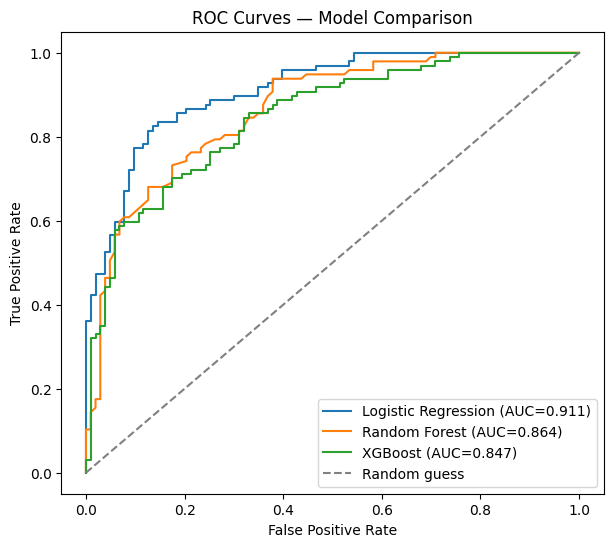

In [85]:
# ROC curves for all three models on one plot
plt.figure(figsize=(7, 6))
for name, model in fitted_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.show()


## 10. Best Model

Pick the winner by whichever metric matters most for your use case:
- **Accuracy** — fine here since classes are near-balanced.
- **F1-score** — best single metric when you care equally about precision & recall.
- **ROC AUC** — best for comparing *ranking/probability quality*, robust to
  threshold choice.

On a dataset this size (1,000 rows), differences between models are often within
noise — don't over-trust a 1-2% gap. Cross-validation (see note below) gives a
more reliable signal than a single train/test split.

In [86]:
best_model_name = results_df['F1-score'].idxmax()
print(f"Best model by F1-score: {best_model_name}")
print(results_df.loc[[best_model_name]])

Best model by F1-score: Logistic Regression
                     Accuracy  Precision    Recall  F1-score  ROC AUC
Model                                                                
Logistic Regression      0.83   0.811881  0.845361  0.828283  0.91072


## 13. Test a Custom Review
Use this helper to enter any review and see the sentiment predicted by the best model selected above. Replace the sample text in the final line with your own review.

In [44]:
def predict_sentiment(review_text):
    """Predict the sentiment of one new review for testing only."""
    if not isinstance(review_text, str) or not review_text.strip():
        raise ValueError("Please enter a non-empty review string.")

    processed_text = preprocess(clean_text(review_text))
    review_vector = tfidf.transform([processed_text])
    model = fitted_models[best_model_name]
    prediction = model.predict(review_vector)[0]
    probability = model.predict_proba(review_vector)[0].max()

    sentiment = le.inverse_transform([prediction])[0]
    print(f"Predicted sentiment: {sentiment}")
    print(f"Confidence: {probability:.2%}")
    return sentiment


predict_sentiment("This movie was wonderfully acted and very entertaining!")

Predicted sentiment: positive
Confidence: 57.23%


'positive'

In [87]:
predict_sentiment("Let me say this about Edward D. Wood Jr. He had a passion for his work that I wish more people did have. If we all had the optimism and the commanding hope of Ed Wood, the world would probably be a much better place. Being familiar with Ed Wood's story and having seen the most wonderful biopic ""Ed Wood"" (1994) several times, I admire his boldness and his strives for the job he loved; I still admire his never-say-die attitude. He had a love for directing that I wish more people in modern-day Hollywood had.<br /><br />But that doesn't make his movies any more fun to watch. And ""Glen or Glenda,"" his first and most confessional film, is probably his very worst.<br /><br />""Glen or Glenda"" is a deadening cult movie about a cross-dresser named Glen (played by director/writer Ed Wood himself) who despite his love for his fiancée Barbara (Dolores Fuller), cannot seem to conquer his lust for transvestitism, in which he dresses in women's clothing and a wig and thus becomes...Glenda! Glen/Glenda's story is narrated by a doctor and he too is talked and watched over by a mysterious character called ""The Scientist"" played by veteran horror star Bela Lugosi. Oh, and there's also some sub-story about an Alan/Anne character who becomes a transsexual based on the Christine Jorgenson story, upon whom this movie originally titled ""I Changed My Sex!"" was previously to be based.<br /><br />Have I dropped your jaw yet? Well, as much as I want to warn you off this picture if you've never seen it, I would never tell a lie about a movie and there is not one word of falsehood in that plot synopsis I just gave you. Every thing in it is true. This is a movie about cross-dressers and transsexuals, a topic that does not sound very appealing to begin with and is not done in a very appealing manner. I'm sure that with a good screenplay, and a good director (it had neither) that ""Glen or Glenda,"" despite the subject matter, could have been a very moving picture. It is a confessional movie on Wood's part, as he was a transvestite in real life as well as on screen. But once again, that does not make it a good movie...or a watchable one for that matter. ""Glen or Glenda"" is a jumbled, disorganized mess of a movie that sinks into new trenches in the realm of bad cinema. It makes no more sense than does its notoriously silly scene where Bela Lugosi screams ""Pull the string!"" over inexplicable footage of stampeding bison. The majority of the movie is narrated in a monotonous voice, reminding me of some very bad short informative films I've seen before. It's like one of those really bad short films expanded into a seventy-minute feature and twice as dull. We sit there for ages waiting for the plot that never comes. There is no real attempt to even build energy with the camera being locked down in one position for many grueling minutes and long stretches of time where nothing at all happens. The only moments that are worth anybody's time are those of Bela Lugosi who manages to bring some light into these dark trenches. I guess Lugosi is supposed to be like the deity of the film, but personally, I couldn't care less who or what he's supposed to be. I'll tell you what he was: A gifted actor who wound up making trash. But he and Wood were very good friends and liked working with each other, so good for him.<br /><br />I will always admire Edward D. Wood Jr. for his passion for the cinema, but I will never as long as I live admire his movies. A film critic once called Ed Wood's movies ""innocent fun"" but I think even that is questionable. Innocent? Yes. Fun? No, sir. And if ""Citizen Kane"" is the Mount Everest of the cinematic world, then ""Glen or Glenda"" is probably the Mariana Trench.")

Predicted sentiment: negative
Confidence: 67.94%


'negative'

In [88]:
predict_sentiment("You are my son")

Predicted sentiment: positive
Confidence: 55.40%


'positive'

**My expectation before you run it:** on a small (1,000-row), roughly
balanced, English-language review dataset with TF-IDF features, **Logistic
Regression** very often matches or beats Random Forest/XGBoost here — linear
models tend to do well on high-dimensional sparse text features, and tree
ensembles need more data to show their advantage and can overfit a 5000-column
TF-IDF matrix built from only ~800 training rows. XGBoost is the one most likely
to close the gap or win if you increase `max_features`/add bigrams and tune
`learning_rate`/`max_depth`. Treat this as a hypothesis to verify with your
actual run, not a guarantee.

## 11. Optional: Cross-Validation (more reliable than one split)

A single train/test split on 1,000 rows has real variance. If you want a more
trustworthy comparison, run 5-fold cross-validation on the *training* pipeline
(not shown as a full re-run here to keep this notebook fast, but this is the
standard next step):

```python
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    print(name, scores.mean(), scores.std())
```

## 12. Summary of Tunable Parameters (quick reference)

| Stage | Parameter | Try values | Effect |
|---|---|---|---|
| TF-IDF | `max_features` | 3000 / 5000 / 10000 | vocabulary size vs overfit risk |
| TF-IDF | `ngram_range` | (1,1) vs (1,2) | captures phrases like "not good" |
| TF-IDF | `min_df` / `max_df` | 2 / 0.9 | drops rare/too-common terms |
| Split | `test_size` | 0.2 / 0.25 / 0.3 | train vs test data amount |
| LogReg | `C` | 0.1 / 1 / 10 | regularization strength |
| LogReg | `penalty` | l1 / l2 | sparsity of weights |
| RF | `n_estimators` | 100 / 300 / 500 | number of trees |
| RF | `max_depth` | None / 20 / 50 | overfitting control |
| XGBoost | `n_estimators` | 200–800 | boosting rounds |
| XGBoost | `learning_rate` | 0.01–0.3 | step size, trade off with n_estimators |
| XGBoost | `max_depth` | 3–8 | tree complexity |
| XGBoost | `subsample`/`colsample_bytree` | 0.7–1.0 | regularization via sampling |

Change one knob at a time, re-run sections 8B–9, and watch how the comparison
table moves — that's the fastest way to build intuition for what each parameter
actually does.